## Business Report Vendite eCommerce

In [1]:
import pandas as pd

Ho 4 file:
* Customer (CSV) - informazioni sul cliente (solo la nazione per la privacy)
* Product (CSV) - informazioni sul prodotto - catalogo dei prodotti con la loro categoria/sub cat
* Transazioni (XLSX) - ultimi 3 mesi
* Transazioni (XLSX) - storico

1. Quali sono i 10 prodotti più venduti?

**Customer**

In [2]:
#inizio a caricare e esaminare i file
dfcu = pd.read_csv("T02-eCommerce-CustomerMD.csv", delimiter=";")
dfcu.head()

,Customer_ID,Country
0,12346,United Kingdom
1,12347,Iceland
2,12348,Finland
3,12349,Italy
4,12350,Norway


In [3]:
dfcu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Customer_ID  5856 non-null   int64 
 1   Country      5856 non-null   object
dtypes: int64(1), object(1)
memory usage: 91.6+ KB


**Prodotti**

In [5]:
dfpr = pd.read_csv("T02-eCommerce-ProductMD.csv", delimiter=',', encoding="latin-1")
dfpr.head()

,StockCode,Description,Category,Subcategory
0,10002R,ROBOT PENCIL SHARPNER,Stationery,Desktop Stationery
1,10109,BENDY COLOUR PENCILS,Stationery,Desktop Stationery
2,10120,DOGGY RUBBER,Stationery,Desktop Stationery
3,10123C,HEARTS WRAPPING TAPE,Stationery,Desktop Stationery
4,10123G,ARMY CAMO WRAPPING TAPE,Stationery,Desktop Stationery


In [6]:
dfpr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3812 entries, 0 to 3811
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   StockCode    3812 non-null   object
 1   Description  3812 non-null   object
 2   Category     3812 non-null   object
 3   Subcategory  3812 non-null   object
dtypes: object(4)
memory usage: 119.3+ KB


**Transazioni**


In [7]:
dftr = pd.read_excel("T02-eCommerce-TransactionsL3M.xlsx", engine="openpyxl")
dftr.head()

c:\Users\paolo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


In [8]:
dftr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130287 entries, 0 to 130286
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       130287 non-null  object 
 1   StockCode     130287 non-null  object 
 2   Quantity      130287 non-null  int64  
 3   Price         130287 non-null  float64
 4   Customer_ID   130287 non-null  int64  
 5   Invoice_time  130287 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 6.0+ MB


In [9]:
#come verifico se i nuna colonna mancano dei dati?
dftr[["Quantity", "Price"]].isna().sum()

Quantity    0
Price       0
dtype: int64

In [10]:
dftrh = pd.read_excel("T02-eCommerce-TransactionsHistory.xlsx", engine='openpyxl')
dftrh.head()

c:\Users\paolo\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,489434,85048,12,6.95,13085,D01/12/17T07:45:00
1,489434,79323P,12,6.75,13085,D01/12/17T07:45:00
2,489434,79323W,12,6.75,13085,D01/12/17T07:45:00
3,489434,22041,48,2.10,13085,D01/12/17T07:45:00
4,489434,21232,24,1.25,13085,D01/12/17T07:45:00


In [11]:
dftrh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545592 entries, 0 to 545591
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       545592 non-null  object 
 1   StockCode     545592 non-null  object 
 2   Quantity      545592 non-null  int64  
 3   Price         545592 non-null  float64
 4   Customer_ID   545592 non-null  int64  
 5   Invoice_time  545592 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 25.0+ MB


Unisco le due tabelle con le transazioni

In [12]:
df_tot = pd.concat([dftr, dftrh], ignore_index=True, sort=False)
df_tot.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00


In [13]:
df_tot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675879 entries, 0 to 675878
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Invoice       675879 non-null  object 
 1   StockCode     675879 non-null  object 
 2   Quantity      675879 non-null  int64  
 3   Price         675879 non-null  float64
 4   Customer_ID   675879 non-null  int64  
 5   Invoice_time  675879 non-null  object 
dtypes: float64(1), int64(2), object(3)
memory usage: 30.9+ MB


Unisco le tabelle Customer e Product alla tabella con le transazioni

In [14]:
customer = dfcu
product = dfpr
transactions = df_tot

In [15]:
transactions2 = transactions.merge(customer, on="Customer_ID", how='left')
transactions2.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom


## Come trovo i 10 prodotti più redditizzi?

* per ogni riga devo aggiungere il valore (qta*prz)
* raggruppo per prodotto
* sommare per gruppo
* ordinare e selezionare i primi 10

In [16]:
transactions2["total_row"] = transactions2["Quantity"] * transactions2["Price"]
transactions2.head()

,Invoice,StockCode,Quantity,Price,Customer_ID,Invoice_time,Country,total_row
0,565080,20677,8,1.25,13509,D01/9/19T08:25:00,United Kingdom,10.0
1,565080,22128,24,1.25,13509,D01/9/19T08:25:00,United Kingdom,30.0
2,565082,22423,2,12.75,13305,D01/9/19T09:15:00,United Kingdom,25.5
3,565082,15060B,8,3.75,13305,D01/9/19T09:15:00,United Kingdom,30.0
4,565082,23245,4,4.95,13305,D01/9/19T09:15:00,United Kingdom,19.8


In [20]:
totale_prodotto = transactions2.groupby("StockCode")["total_row"].sum().reset_index()
totale_prodotto.head(10)

,StockCode,total_row
0,10109,1.68
1,10120,131.88
2,10123C,216.82
3,10123G,90.94
4,10124A,26.04
5,10124G,15.54
6,10125,1579.70
7,10133,1930.76
8,10134,692.30
9,10135,3980.96


In [22]:
#ordino il dataframe
totale_prodotto.sort_values(by="total_row", ascending=False, inplace=True)
totale_prodotto.head(10)

,StockCode,total_row
1375,22423,265295.62
3169,85123A,240707.67
3153,85099B,166451.16
2988,84879,124354.72
3571,POST,109511.60
2452,47566,102220.93
1128,22086,74510.46
2646,79321,70118.67
1355,22386,66771.74
2483,48138,64128.57


In [23]:
#aggiungo a totale_prodotto la tabella con le descrizioni dei prodotti
totale_prodotto_desc = totale_prodotto.merge(product, on="StockCode", how='left')
totale_prodotto_desc.head(10)

,StockCode,total_row,Description,Category,Subcategory
0,22423,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,85123A,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,85099B,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,84879,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,POST,109511.60,POSTAGE,Others,Code
5,47566,102220.93,PARTY BUNTING,Kids,Party
6,22086,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,79321,70118.67,CHILLI LIGHTS,Home,Furniture
8,22386,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,48138,64128.57,DOORMAT UNION FLAG,Home,Furniture


In [25]:
#elimino le colonne inutili

report = totale_prodotto_desc.head(10).copy()
report


,StockCode,total_row,Description,Category,Subcategory
0,22423,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,85123A,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,85099B,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,84879,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,POST,109511.60,POSTAGE,Others,Code
5,47566,102220.93,PARTY BUNTING,Kids,Party
6,22086,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,79321,70118.67,CHILLI LIGHTS,Home,Furniture
8,22386,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,48138,64128.57,DOORMAT UNION FLAG,Home,Furniture


In [ ]:
report.drop(columns=["StockCode"], inplace=True)

KeyError: "['StockCode'] not found in axis"

In [28]:
report

,total_row,Description,Category,Subcategory
0,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,109511.60,POSTAGE,Others,Code
5,102220.93,PARTY BUNTING,Kids,Party
6,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,70118.67,CHILLI LIGHTS,Home,Furniture
8,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,64128.57,DOORMAT UNION FLAG,Home,Furniture


In [29]:
report.rename(columns={"total_row":"totale", "Description":"prodotto"}, inplace=True)
report

,totale,prodotto,Category,Subcategory
0,265295.62,REGENCY CAKESTAND 3 TIER,Home,Kitchen
1,240707.67,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles
2,166451.16,JUMBO BAG RED RETROSPOT,Accessories,Bags
3,124354.72,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration
4,109511.60,POSTAGE,Others,Code
5,102220.93,PARTY BUNTING,Kids,Party
6,74510.46,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas
7,70118.67,CHILLI LIGHTS,Home,Furniture
8,66771.74,JUMBO BAG PINK POLKADOT,Accessories,Bags
9,64128.57,DOORMAT UNION FLAG,Home,Furniture


In [30]:
#sposto le colonne
report = report[ ["prodotto", "Category", "Subcategory", "totale"] ]
report

,prodotto,Category,Subcategory,totale
0,REGENCY CAKESTAND 3 TIER,Home,Kitchen,265295.62
1,WHITE HANGING HEART T-LIGHT HOLDER,Air fragances,Candles,240707.67
2,JUMBO BAG RED RETROSPOT,Accessories,Bags,166451.16
3,ASSORTED COLOUR BIRD ORNAMENT,Home,Decoration,124354.72
4,POSTAGE,Others,Code,109511.60
5,PARTY BUNTING,Kids,Party,102220.93
6,PAPER CHAIN KIT 50'S CHRISTMAS,Seasonal,Christmas,74510.46
7,CHILLI LIGHTS,Home,Furniture,70118.67
8,JUMBO BAG PINK POLKADOT,Accessories,Bags,66771.74
9,DOORMAT UNION FLAG,Home,Furniture,64128.57


Creo un grafico con matplotlib

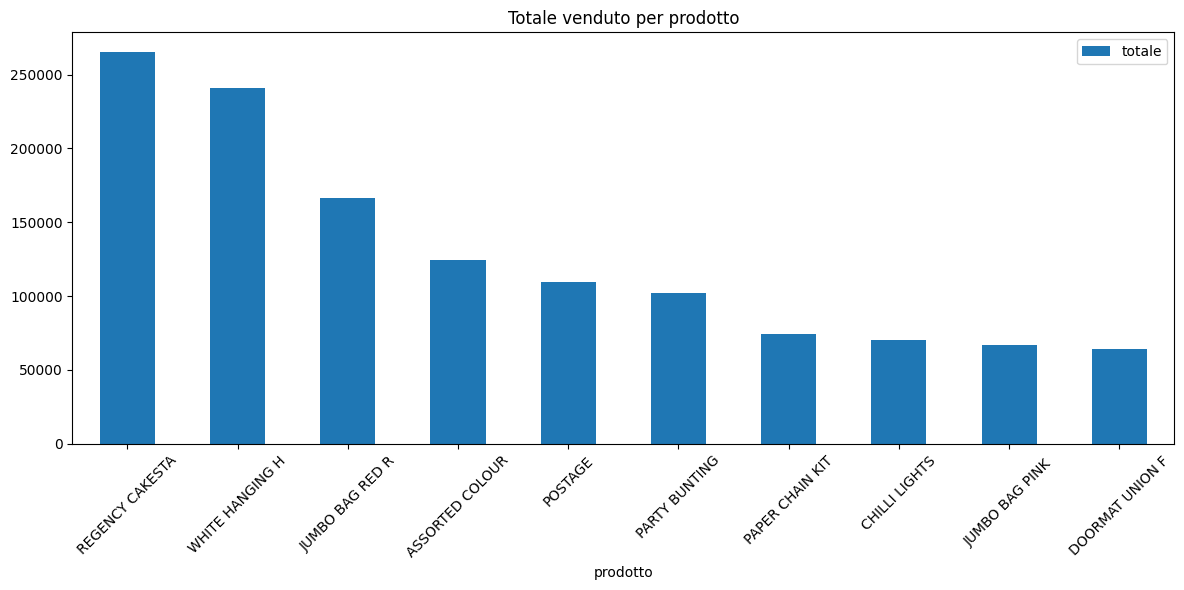

In [36]:
import matplotlib.pyplot as plt

report["prodotto"] = report["prodotto"].str[:15]

report.plot(kind="bar", x="prodotto", y="totale", title="Totale venduto per prodotto", figsize=(12,6))
plt.xticks(rotation=45)
plt.tight_layout()

## Cosa fare dopo?

* Trovare i totali per ogni sottocategoria
* Creare un report di vendite per mese